# Arabic Phishing Detection Project

هذا الدفتر **Google Colab**، ويشمل:

- قراءة ملفات **Train / Validation / Test**
- تنظيف وفحص البيانات
- تدريب وتقييم **SVM**
- تدريب وتقييم **AraBERT**


- مقارنة النتائج النهائية مع نماذج **Hybird**



- حفظ النتائج والملفات النهائية

In [48]:
!pip install -q transformers datasets accelerate scikit-learn sentencepiece arabert

# تحميل المكتبات وتهيأءة البيئة للمشروع

In [49]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

In [50]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seed fixed:", SEED)
print("CUDA available:", torch.cuda.is_available())

Seed fixed: 42
CUDA available: True


## رفع الملفات إلى Colab

In [51]:
TRAIN_FILE = "merged_train_enhanced.csv"
VALID_FILE = "merged_valid_enhanced.csv"
TEST_FILE  = "merged_test_enhanced.csv"

train_df = pd.read_csv(TRAIN_FILE)
valid_df = pd.read_csv(VALID_FILE)
test_df  = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape :", test_df.shape)


Train shape: (7193, 2)
Valid shape: (1675, 2)
Test shape : (2675, 2)


In [52]:
display(train_df.head())
display(valid_df.head())
display(test_df.head())

print("Train label distribution:")
print(train_df["label"].value_counts(dropna=False), "\n")

print("Valid label distribution:")
print(valid_df["label"].value_counts(dropna=False), "\n")

print("Test label distribution:")
print(test_df["label"].value_counts(dropna=False))

,text,label
0,تم استلام مستنداتك لدى جامعة الأميرة نورة. رقم...,0
1,خدمة العملاء: مرحبًا، تم تعذر تسليم شحنتك من س...,0
2,تم تحديث حالة الطلب في نمشي إلى: قيد التجهيز. ...,0
3,مرحبًا لولوة، تم استرداد مبلغ 199.00 ريال إلى ...,0
4,"إشعار من نون: تم تسجيل طلب استرجاع بقيمة 3,480...",0


,text,label
0,تنويه من جامعة الملك سعود: اعتمدت الجهة التعلي...,0
1,تنويه من جامعة الأميرة نورة: سُجل دخول طبيعي إ...,0
2,تنويه من مصرف الراجحي: أظهر سجل الحماية عملية ...,0
3,تنويه من بنك الأهلي السعودي: اكتملت مراجعة حرك...,0
4,تنويه من إكسترا: بدأ تجهيز الطلب لدى المستودع،...,0


,text,label
0,إشعار رسمي: من تامين بوبا: تمت العملية بنجاح. ...,0
1,للمتابعة: من DHL: تعذر تنفيذ موعد التسليم تلقا...,0
2,إشعار رسمي: من أبيان: توجد مراجعة آلية على بيا...,0
3,إشعار رسمي: من أرامكس: يوجد إشعار بخصوص بيان ا...,0
4,إشعار رسمي: من توكلنا: تم تغيير حالة الهوية ال...,0


Train label distribution:
label
1    3598
0    3595
Name: count, dtype: int64 

Valid label distribution:
label
0    838
1    837
Name: count, dtype: int64 

Test label distribution:
label
0    1873
1     802
Name: count, dtype: int64


## تنظيف مبدئي للبيانات

In [53]:
REQUIRED_COLUMNS = ["text", "label"]

def basic_clean_df(df, name="df"):
    df = df.copy()

    for col in REQUIRED_COLUMNS:
        if col not in df.columns:
            raise ValueError(f"{name} is missing required column: {col}")

    df["text"] = df["text"].astype(str).fillna("").str.strip()
    df["label"] = pd.to_numeric(df["label"], errors="coerce")

    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)

    df = df[df["text"].str.len() > 0].copy()
    df = df[df["label"].isin([0, 1])].copy()
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

    return df

train_df = basic_clean_df(train_df, "train_df")
valid_df = basic_clean_df(valid_df, "valid_df")
test_df  = basic_clean_df(test_df, "test_df")

print("After basic cleaning:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

After basic cleaning:
Train: (7193, 2)
Valid: (1675, 2)
Test : (2675, 2)


## استكشاف وتحليل البيانات (EDA)
> تحليل بصري لتوزيع الفئات وأطوال النصوص

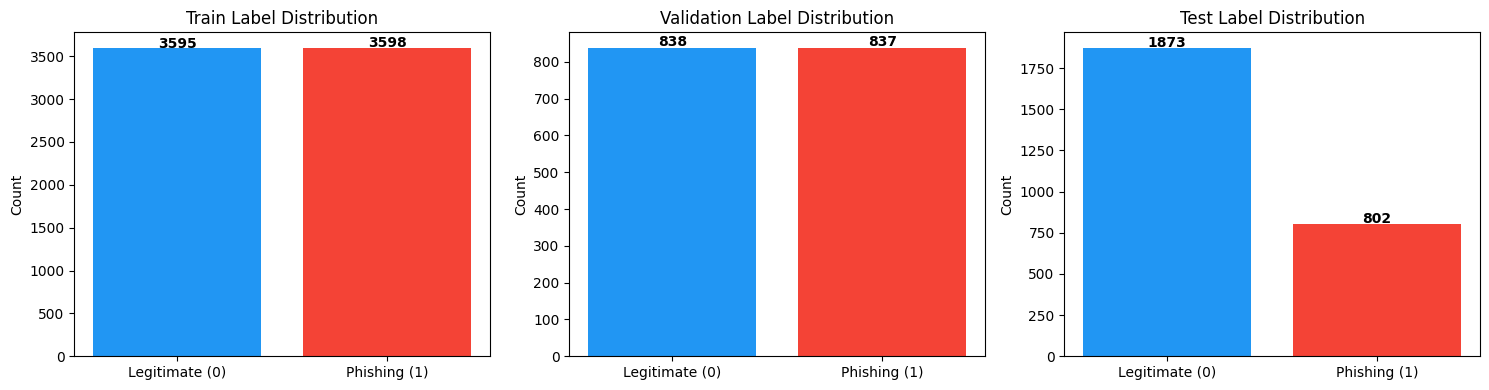

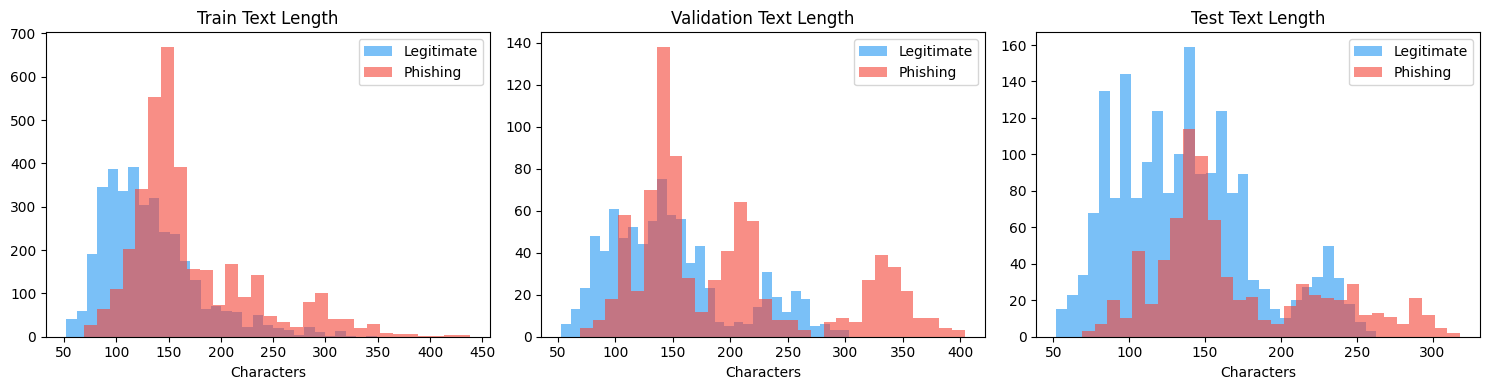

Average text lengths:
  Train: 152 chars
  Valid: 172 chars
  Test: 147 chars


In [54]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Validation', valid_df), ('Test', test_df)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Legitimate (0)', 'Phishing (1)'], counts.values, color=['#2196F3', '#F44336'])
    ax.set_title(f'{name} Label Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Text length distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Validation', valid_df), ('Test', test_df)]):
    df['text_len'] = df['text'].astype(str).apply(len)
    ax.hist(df[df['label']==0]['text_len'], bins=30, alpha=0.6, label='Legitimate', color='#2196F3')
    ax.hist(df[df['label']==1]['text_len'], bins=30, alpha=0.6, label='Phishing', color='#F44336')
    ax.set_title(f'{name} Text Length')
    ax.set_xlabel('Characters')
    ax.legend()
plt.tight_layout()
plt.show()

print('Average text lengths:')
for name, df in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    print(f'  {name}: {df["text"].astype(str).apply(len).mean():.0f} chars')


### تحليل نتائج الاستكشاف (EDA Analysis)

**توزيع الفئات:**
- بيانات التدريب متوازنة تمامًا (1575 لكل فئة)، مما يزيل التحيز أثناء التعلم.
- بيانات التحقق متوازنة تقريبًا (338 مقابل 337).
-  بيانات الاختبار غير متوازنة (473 سليمة مقابل 202 تصيّد بنسبة 70:30).


**أطوال النصوص:**
- متوسط أطوال نصوص التدريب (175 حرفًا) أقل من التحقق (232) والاختبار (204).
- يشير ذلك إلى أن بيانات التحقق والاختبار تحتوي على نصوص أكثر تعقيدًا.

## Normalization للنصوص لاكتشاف التسرب الحقيقي
> نستخدمها فقط لفحص التطابق، وليس كبديل مباشر للنص الأصلي في التدريب.

In [55]:
def normalize_text(text):
    text = str(text).strip().lower()

    text = re.sub(r'https?://\S+|www\.\S+', ' <URL> ', text)
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' <EMAIL> ', text)
    text = re.sub(r'@\w+', ' <USER> ', text)
    text = re.sub(r'#\w+', ' <HASHTAG> ', text)

    text = re.sub(r'[٠-٩]', '0', text)
    text = re.sub(r'\d+', '0', text)

    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)

    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub(r'[^\w\s<>]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

for df in [train_df, valid_df, test_df]:
    df["norm_text"] = df["text"].apply(normalize_text)

display(train_df[["text", "norm_text"]].head())

,text,norm_text
0,تم استلام مستنداتك لدى جامعة الأميرة نورة. رقم...,تم استلام مستنداتك لدي جامعه الاميره نوره رقم ...
1,خدمة العملاء: مرحبًا، تم تعذر تسليم شحنتك من س...,خدمه العملاء مرحبا تم تعذر تسليم شحنتك من سمسا...
2,تم تحديث حالة الطلب في نمشي إلى: قيد التجهيز. ...,تم تحديث حاله الطلب في نمشي الي قيد التجهيز يم...
3,مرحبًا لولوة، تم استرداد مبلغ 199.00 ريال إلى ...,مرحبا لولوه تم استرداد مبلغ 0 0 ريال الي محفظت...
4,"إشعار من نون: تم تسجيل طلب استرجاع بقيمة 3,480...",اشعار من نون تم تسجيل طلب استرجاع بقيمه 0 0 0 ...


## إزالة التسرب الحقيقي فقط
نزيل فقط **exact duplicates after normalization** بين `Train` و `Validation/Test`.

In [56]:
train_norm_set = set(train_df["norm_text"])

valid_clean = valid_df[~valid_df["norm_text"].isin(train_norm_set)].copy()
test_clean  = test_df[~test_df["norm_text"].isin(train_norm_set)].copy()

valid_norm_set = set(valid_clean["norm_text"])
test_clean = test_clean[~test_clean["norm_text"].isin(valid_norm_set)].copy()

valid_clean = valid_clean.reset_index(drop=True)
test_clean  = test_clean.reset_index(drop=True)

print("After exact leakage removal:")
print("Train:", len(train_df))
print("Valid clean:", len(valid_clean))
print("Test clean :", len(test_clean))

After exact leakage removal:
Train: 7193
Valid clean: 798
Test clean : 935


In [57]:
if len(valid_clean) == 0:
    raise ValueError("Validation set became empty after exact leakage removal.")

if len(test_clean) == 0:
    raise ValueError("Test set became empty after exact leakage removal.")

print("Validation and Test are safe to use.")

Validation and Test are safe to use.


## حفظ النسخ النظيفة

In [58]:
train_clean = train_df.copy()

train_clean.to_csv("train_clean_final.csv", index=False, encoding="utf-8-sig")
valid_clean.to_csv("valid_clean_final.csv", index=False, encoding="utf-8-sig")
test_clean.to_csv("test_clean_final.csv", index=False, encoding="utf-8-sig")

print("Saved cleaned files.")

Saved cleaned files.


# الجزء الأول: SVM

In [59]:
sample_train = train_clean["text"].astype(str).tolist()
y_train = train_clean["label"].astype(int).tolist()

sample_valid = valid_clean["text"].astype(str).tolist()
y_valid = valid_clean["label"].astype(int).tolist()

sample_test = test_clean["text"].astype(str).tolist()
y_test = test_clean["label"].astype(int).tolist()

print("SVM sizes:")
print("Train:", len(sample_train))
print("Valid:", len(sample_valid))
print("Test :", len(sample_test))

SVM sizes:
Train: 7193
Valid: 798
Test : 935


In [60]:
classes = np.array(sorted(train_clean["label"].unique()))
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_clean["label"].values
)

class_weight_dict = {cls: w for cls, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.0004172461752434), np.int64(1): np.float64(0.9995831017231795)}


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Define the base pipeline
svm_base_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        min_df=2,
        max_df=0.90,
        sublinear_tf=True,
        strip_accents=None,
        lowercase=True
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ))
])

# Hyperparameter tuning with GridSearchCV
param_grid = {
    "clf__C": [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0],
    "tfidf__ngram_range": [ (1,3)]
}

grid_search = GridSearchCV(
    svm_base_pipeline, param_grid,
    cv=5, scoring="f1", n_jobs=-1, verbose=1
)

grid_search.fit(sample_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-score:", round(grid_search.best_score_, 4))

svm_pipeline = grid_search.best_estimator_
print("\nOptimized SVM Pipeline Ready")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters: {'clf__C': 0.3, 'tfidf__ngram_range': (1, 3)}
Best CV F1-score: 0.9993

Optimized SVM Pipeline Ready


In [62]:
# No need to re-fit - GridSearchCV already trained the best model
valid_pred_svm = svm_pipeline.predict(sample_valid)

print("=== SVM Validation Results ===")
print("Accuracy :", accuracy_score(y_valid, valid_pred_svm))
print("Precision:", precision_score(y_valid, valid_pred_svm))
print("Recall   :", recall_score(y_valid, valid_pred_svm))
print("F1-score :", f1_score(y_valid, valid_pred_svm))

print("\nClassification Report (Validation):")
print(classification_report(y_valid, valid_pred_svm, digits=4))

=== SVM Validation Results ===
Accuracy : 0.9862155388471178
Precision: 0.9750623441396509
Recall   : 0.9974489795918368
F1-score : 0.9861286254728878

Classification Report (Validation):
              precision    recall  f1-score   support

           0     0.9975    0.9754    0.9863       406
           1     0.9751    0.9974    0.9861       392

    accuracy                         0.9862       798
   macro avg     0.9863    0.9864    0.9862       798
weighted avg     0.9865    0.9862    0.9862       798



In [63]:
test_pred_svm = svm_pipeline.predict(sample_test)

print("=== SVM Test Results ===")
print("Accuracy :", accuracy_score(y_test, test_pred_svm))
print("Precision:", precision_score(y_test, test_pred_svm))
print("Recall   :", recall_score(y_test, test_pred_svm))
print("F1-score :", f1_score(y_test, test_pred_svm))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred_svm, digits=4))

=== SVM Test Results ===
Accuracy : 0.9208556149732621
Precision: 0.8231292517006803
Recall   : 0.9166666666666666
F1-score : 0.8673835125448028

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.9657    0.9225    0.9436       671
           1     0.8231    0.9167    0.8674       264

    accuracy                         0.9209       935
   macro avg     0.8944    0.9196    0.9055       935
weighted avg     0.9254    0.9209    0.9221       935



In [64]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scores for Soft Voting
svm_scores = svm_pipeline.decision_function(sample_test)

scaler = MinMaxScaler()
svm_probs = scaler.fit_transform(
    np.array(svm_scores).reshape(-1,1)
).ravel()

# Save file
svm_results = pd.DataFrame({
    "text": sample_test,
    "true_label": y_test,
    "svm_pred": test_pred_svm,
    "svm_prob": svm_probs
})

svm_results.to_csv("svm_test_predictions.csv", index=False, encoding="utf-8-sig")

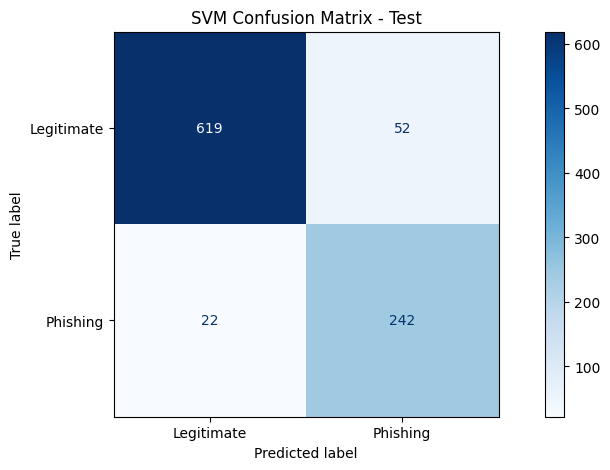

In [65]:
cm = confusion_matrix(y_test, test_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix - Test")
plt.show()

### SVM ROC Curve

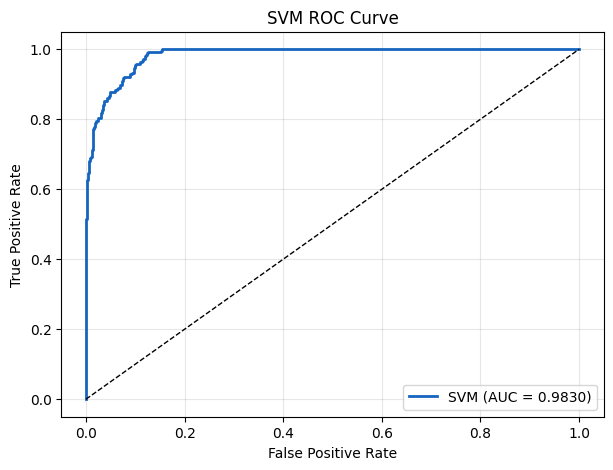

SVM AUC: 0.9830


In [66]:
from sklearn.metrics import roc_curve, auc

# SVM decision scores for ROC
svm_scores = svm_pipeline.decision_function(sample_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, color='#1565C0', lw=2, label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f'SVM AUC: {auc_svm:.4f}')


# الجزء الثاني: AraBERT

In [67]:
from arabert.preprocess import ArabertPreprocessor

MODEL_NAME = "aubmindlab/bert-base-arabertv02"

arabert_prep = ArabertPreprocessor(model_name=MODEL_NAME)

print("Model:", MODEL_NAME)

Model: aubmindlab/bert-base-arabertv02


In [68]:
train_bert = train_clean[["text", "label"]].rename(columns={"label": "labels"}).copy()
valid_bert = valid_clean[["text", "label"]].rename(columns={"label": "labels"}).copy()
test_bert  = test_clean[["text", "label"]].rename(columns={"label": "labels"}).copy()

train_bert["text"] = train_bert["text"].astype(str).apply(arabert_prep.preprocess)
valid_bert["text"] = valid_bert["text"].astype(str).apply(arabert_prep.preprocess)
test_bert["text"]  = test_bert["text"].astype(str).apply(arabert_prep.preprocess)

print(train_bert.shape, valid_bert.shape, test_bert.shape)

(7193, 2) (798, 2) (935, 2)


In [69]:
train_dataset = Dataset.from_pandas(train_bert, preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_bert, preserve_index=False)
test_dataset  = Dataset.from_pandas(test_bert, preserve_index=False)

In [70]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [71]:
MAX_LEN = 128  # Reduced from 256 to fit in local GPU memory

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7193 [00:00<?, ? examples/s]

Map:   0%|          | 0/798 [00:00<?, ? examples/s]

Map:   0%|          | 0/935 [00:00<?, ? examples/s]

In [72]:
columns_to_return = ["input_ids", "attention_mask", "labels"]

if "token_type_ids" in train_dataset.column_names:
    columns_to_return.append("token_type_ids")

train_dataset.set_format(type="torch", columns=columns_to_return)
valid_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

print("Dataset format ready.")

Dataset format ready.


In [73]:
# Free GPU memory before loading model
import gc
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [74]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

In [75]:
training_args = TrainingArguments(
    output_dir="./arabert_results_v2",

    do_train=True,
    do_eval=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    per_device_train_batch_size=16
    ,
    per_device_eval_batch_size=32,

    gradient_accumulation_steps=8,
    lr_scheduler_type = "cosine",
    label_smoothing_factor = 0.1,

    num_train_epochs=5,

    learning_rate = 2e-5,
    weight_decay=0.01,
    warmup_steps=197, # Calculated as 0.1 * (len(train_dataset) / per_device_train_batch_size) * num_train_epochs

    save_total_limit=2,
    report_to="none",

    seed=42,

    gradient_checkpointing=True,  # Saves VRAM by recomputing activations

    fp16=torch.cuda.is_available()
)

In [76]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [77]:
torch.cuda.empty_cache()
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,5.038884,0.669714,0.621554,0.620968,0.589286,0.604712
2,2.141355,0.262607,0.964912,0.955000,0.974490,0.964646
3,1.591227,0.246532,0.972431,0.946860,1.000000,0.972705
4,1.584533,0.351335,0.903509,0.993730,0.808673,0.891702
5,1.581411,0.223648,0.982456,0.972500,0.992347,0.982323


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=285, training_loss=2.3874820910002055, metrics={'train_runtime': 529.3401, 'train_samples_per_second': 67.943, 'train_steps_per_second': 0.538, 'total_flos': 2365697276505600.0, 'train_loss': 2.3874820910002055, 'epoch': 5.0})

In [78]:
# ==================================
# Save Final AraBERT Model
# ==================================

SAVE_PATH = "/content/arabert_phishing_model_finalWeb"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("AraBERT model saved successfully at:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

AraBERT model saved successfully at: /content/arabert_phishing_model_finalWeb


In [79]:
# ==================================
# Zip + Download Model
# ==================================

!zip -r arabert_phishing_model_final.zip /content/arabert_phishing_model_finalWeb

from google.colab import files
files.download("arabert_phishing_model_final.zip")

  adding: content/arabert_phishing_model_finalWeb/ (stored 0%)
  adding: content/arabert_phishing_model_finalWeb/training_args.bin (deflated 53%)
  adding: content/arabert_phishing_model_finalWeb/config.json (deflated 51%)
  adding: content/arabert_phishing_model_finalWeb/tokenizer.json (deflated 74%)
  adding: content/arabert_phishing_model_finalWeb/tokenizer_config.json (deflated 43%)
  adding: content/arabert_phishing_model_finalWeb/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### حفظ النموذج المُدرَّب

In [80]:
# Save the fine-tuned AraBERT model
trainer.save_model('./arabert_phishing_model_final')
tokenizer.save_pretrained('./arabert_phishing_model_final')
print('AraBERT model saved to ./arabert_phishing_model_final')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

AraBERT model saved to ./arabert_phishing_model_final


In [81]:
from sklearn.metrics import f1_score
import numpy as np
import torch

valid_pred_output = trainer.predict(valid_dataset)

valid_logits = valid_pred_output.predictions
valid_probs = torch.softmax(torch.tensor(valid_logits), dim=1).numpy()[:,1]
valid_true = valid_pred_output.label_ids

best_threshold = 0.5
best_f1 = 0

for th in np.arange(0.30, 0.71, 0.02):
    preds = (valid_probs >= th).astype(int)
    score = f1_score(valid_true, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = th

print("Best Threshold =", best_threshold)
print("Best Validation F1 =", best_f1)

Best Threshold = 0.6000000000000003
Best Validation F1 = 0.9885350318471338


In [82]:
valid_results = trainer.evaluate(valid_dataset)
print("AraBERT Validation Results:")
print(valid_results)

AraBERT Validation Results:
{'eval_loss': 0.22364778816699982, 'eval_accuracy': 0.9824561403508771, 'eval_precision': 0.9725, 'eval_recall': 0.9923469387755102, 'eval_f1': 0.9823232323232324, 'eval_runtime': 1.4068, 'eval_samples_per_second': 567.235, 'eval_steps_per_second': 17.771, 'epoch': 5.0}


In [83]:
test_results = trainer.evaluate(test_dataset)
print("AraBERT Test Results:")
print(test_results)

AraBERT Test Results:
{'eval_loss': 0.23000626266002655, 'eval_accuracy': 0.9818181818181818, 'eval_precision': 0.9591078066914498, 'eval_recall': 0.9772727272727273, 'eval_f1': 0.9681050656660413, 'eval_runtime': 1.6974, 'eval_samples_per_second': 550.831, 'eval_steps_per_second': 17.674, 'epoch': 5.0}


In [84]:
test_pred_output = trainer.predict(test_dataset)

test_logits = test_pred_output.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()[:,1]

true_labels = test_pred_output.label_ids

pred_labels = (test_probs >= best_threshold).astype(int)

print("Accuracy :", accuracy_score(true_labels, pred_labels))
print("Precision:", precision_score(true_labels, pred_labels))
print("Recall   :", recall_score(true_labels, pred_labels))
print("F1-score :", f1_score(true_labels, pred_labels))

print(classification_report(true_labels, pred_labels, digits=4))

Accuracy : 0.9828877005347594
Precision: 0.9661654135338346
Recall   : 0.9734848484848485
F1-score : 0.969811320754717
              precision    recall  f1-score   support

           0     0.9895    0.9866    0.9881       671
           1     0.9662    0.9735    0.9698       264

    accuracy                         0.9829       935
   macro avg     0.9779    0.9800    0.9789       935
weighted avg     0.9829    0.9829    0.9829       935



In [85]:
# ==================================
# AraBERT Predictions + Probabilities
# ==================================

import numpy as np
from scipy.special import softmax

logits = test_pred_output.predictions

# labels
pred_labels = np.argmax(logits, axis=1)

# phishing probability (class 1)
test_probs = softmax(logits, axis=1)[:,1]

print("Predictions ready.")
print("Shape:", pred_labels.shape)

Predictions ready.
Shape: (935,)


In [86]:
# ==================================
# Save AraBERT Test Results
# ==================================

bert_results = pd.DataFrame({
    "text": sample_test,
    "true_label": true_labels,
    "arabert_pred": pred_labels,
    "arabert_prob": test_probs
})

bert_results.to_csv(
    "arabert_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("arabert_test_predictions.csv saved.")

arabert_test_predictions.csv saved.


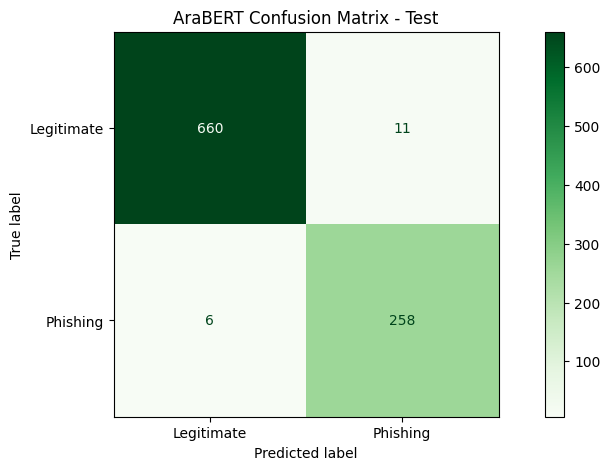

In [87]:
cm_bert = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Greens")
plt.title("AraBERT Confusion Matrix - Test")
plt.show()

### ROC Curve Comparison

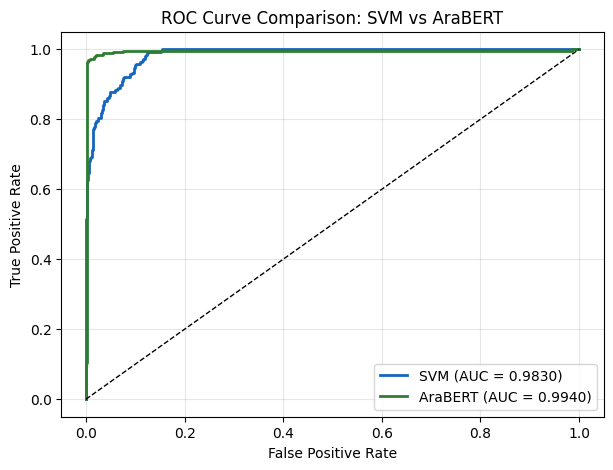

In [88]:
# AraBERT ROC
fpr_bert, tpr_bert, _ = roc_curve(true_labels, test_probs)
auc_bert = auc(fpr_bert, tpr_bert)

# Combined ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, color='#1565C0', lw=2, label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot(fpr_bert, tpr_bert, color='#2E7D32', lw=2, label=f'AraBERT (AUC = {auc_bert:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: SVM vs AraBERT')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# مقارنة نهائية بين النموذجين

In [89]:
svm_acc = accuracy_score(y_test, test_pred_svm)
svm_prec = precision_score(y_test, test_pred_svm)
svm_rec = recall_score(y_test, test_pred_svm)
svm_f1 = f1_score(y_test, test_pred_svm)

bert_acc = accuracy_score(true_labels, pred_labels)
bert_prec = precision_score(true_labels, pred_labels)
bert_rec = recall_score(true_labels, pred_labels)
bert_f1 = f1_score(true_labels, pred_labels)

comparison_df = pd.DataFrame({
    "Model": ["SVM", "AraBERT"],
    "Accuracy": [svm_acc, bert_acc],
    "Precision": [svm_prec, bert_prec],
    "Recall": [svm_rec, bert_rec],
    "F1-score": [svm_f1, bert_f1]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.920856,0.823129,0.916667,0.867384
1,AraBERT,0.981818,0.959108,0.977273,0.968105


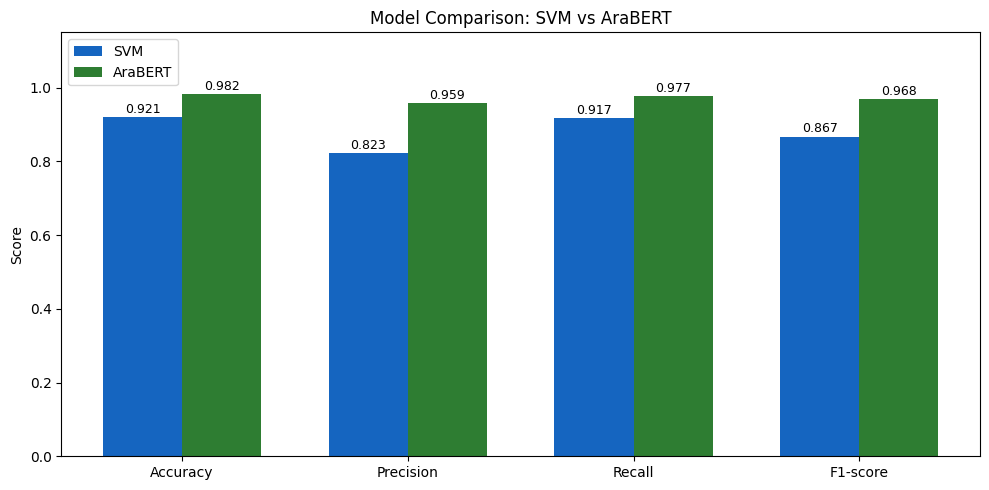

In [90]:
# Visual comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
svm_vals = [svm_acc, svm_prec, svm_rec, svm_f1]
bert_vals = [bert_acc, bert_prec, bert_rec, bert_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, svm_vals, width, label='SVM', color='#1565C0')
bars2 = ax.bar(x + width/2, bert_vals, width, label='AraBERT', color='#2E7D32')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: SVM vs AraBERT')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.15)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [91]:
# McNemar's Test for Statistical Significance
from scipy.stats import chi2

svm_correct = (np.array(y_test) == np.array(test_pred_svm))
bert_correct = (np.array(true_labels) == np.array(pred_labels))

a = np.sum(svm_correct & bert_correct)
b = np.sum(svm_correct & ~bert_correct)
c = np.sum(~svm_correct & bert_correct)
d = np.sum(~svm_correct & ~bert_correct)

print('McNemar Contingency Table:')
print(f'  Both Correct:               {a}')
print(f'  SVM Correct, AraBERT Wrong:  {b}')
print(f'  SVM Wrong, AraBERT Correct:  {c}')
print(f'  Both Wrong:                  {d}')

if b + c > 0:
    mcnemar_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value = 1 - chi2.cdf(mcnemar_stat, df=1)
    print(f'\nMcNemar Statistic: {mcnemar_stat:.4f}')
    print(f'P-value: {p_value:.4f}')
    if p_value < 0.05:
        print('Result: Statistically significant (p < 0.05)')
    else:
        print('Result: NOT statistically significant (p >= 0.05)')
else:
    print('Cannot compute: b + c = 0')


McNemar Contingency Table:
  Both Correct:               855
  SVM Correct, AraBERT Wrong:  6
  SVM Wrong, AraBERT Correct:  63
  Both Wrong:                  11

McNemar Statistic: 45.4493
P-value: 0.0000
Result: Statistically significant (p < 0.05)


In [92]:
comparison_df.to_csv("model_comparison_results.csv", index=False, encoding="utf-8-sig")

svm_predictions_df = pd.DataFrame({
    "text": sample_test,
    "true_label": y_test,
    "svm_pred": test_pred_svm,
    "svm_prob": svm_probs # Include svm_prob here as well
})
svm_predictions_df.to_csv("svm_test_predictions.csv", index=False, encoding="utf-8-sig")

bert_predictions_df = pd.DataFrame({
    "text": test_clean["text"].tolist(),
    "true_label": true_labels,
    "arabert_pred": pred_labels,
    "arabert_prob": test_probs # Add arabert_prob here
})
bert_predictions_df.to_csv("arabert_test_predictions.csv", index=False, encoding="utf-8-sig")

print("All results saved.")

All results saved.


In [93]:
# =====================================================
# Hybrid Step 1: Get SVM probabilities on validation set
# =====================================================
from sklearn.preprocessing import MinMaxScaler

svm_valid_scores = svm_pipeline.decision_function(sample_valid)
scaler_valid = MinMaxScaler()
svm_valid_probs = scaler_valid.fit_transform(
    np.array(svm_valid_scores).reshape(-1, 1)
).ravel()

# Also re-scale test scores using same scaler for consistency
svm_test_scaled = scaler_valid.transform(
    np.array(svm_pipeline.decision_function(sample_test)).reshape(-1, 1)
).ravel()

print(" SVM probabilities ready")
print("  Valid sample:", svm_valid_probs[:5].round(4))
print("  Test  sample:", svm_test_scaled[:5].round(4))

 SVM probabilities ready
  Valid sample: [0.1324 0.2788 0.4786 0.3767 0.1122]
  Test  sample: [0.2224 0.4975 0.1443 0.2831 0.3557]


In [94]:
# =====================================================
# Hybrid Step 2: Soft Voting Ensemble (Weighted Average)
# =====================================================
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)

# valid_probs  = AraBERT probs on validation (from cell 48)
# test_probs   = AraBERT probs on test       (from cell 51/52)
# svm_valid_probs = SVM probs on validation  (cell above)
# svm_test_scaled = SVM probs on test        (cell above)

ensemble_results = []

for svm_w in np.arange(0.1, 1.0, 0.1):
    bert_w = round(1.0 - svm_w, 1)

    # Find best threshold on VALIDATION
    best_th, best_f1_v = 0.5, 0.0
    for th in np.arange(0.30, 0.71, 0.02):
        hybrid_valid = svm_w * svm_valid_probs + bert_w * valid_probs
        preds = (hybrid_valid >= th).astype(int)
        sc = f1_score(valid_true, preds)
        if sc > best_f1_v:
            best_f1_v, best_th = sc, th

    # Evaluate on TEST
    hybrid_test = svm_w * svm_test_scaled + bert_w * test_probs
    hybrid_preds = (hybrid_test >= best_th).astype(int)

    ensemble_results.append({
        "SVM Weight":  round(svm_w, 1),
        "BERT Weight": bert_w,
        "Threshold":   round(best_th, 2),
        "Accuracy":    round(accuracy_score(y_test, hybrid_preds), 4),
        "Precision":   round(precision_score(y_test, hybrid_preds), 4),
        "Recall":      round(recall_score(y_test, hybrid_preds), 4),
        "F1-score":    round(f1_score(y_test, hybrid_preds), 4),
    })

ensemble_df = pd.DataFrame(ensemble_results)
print("=== Soft Voting Ensemble Results ===")
display(ensemble_df.sort_values("F1-score", ascending=False))

best_row = ensemble_df.sort_values("F1-score", ascending=False).iloc[0]
print(f"\nBest: SVM={best_row['SVM Weight']}  BERT={best_row['BERT Weight']}"
      f"  Threshold={best_row['Threshold']}  F1={best_row['F1-score']}")

=== Soft Voting Ensemble Results ===


,SVM Weight,BERT Weight,Threshold,Accuracy,Precision,Recall,F1-score
5,0.6,0.4,0.58,0.9840,0.9698,0.9735,0.9716
3,0.4,0.6,0.58,0.9829,0.9662,0.9735,0.9698
4,0.5,0.5,0.58,0.9829,0.9662,0.9735,0.9698
0,0.1,0.9,0.60,0.9818,0.9625,0.9735,0.9680
2,0.3,0.7,0.58,0.9818,0.9625,0.9735,0.9680
1,0.2,0.8,0.58,0.9818,0.9625,0.9735,0.9680
7,0.8,0.2,0.56,0.9797,0.9623,0.9659,0.9641
6,0.7,0.3,0.48,0.9701,0.9184,0.9811,0.9487
8,0.9,0.1,0.56,0.9572,0.9308,0.9167,0.9237



Best: SVM=0.6  BERT=0.4  Threshold=0.58  F1=0.9716


=== Stacking Results ===
Accuracy : 0.9807
Precision: 0.959
Recall   : 0.9735
F1-score : 0.9662

              precision    recall  f1-score   support

           0     0.9895    0.9836    0.9865       671
           1     0.9590    0.9735    0.9662       264

    accuracy                         0.9807       935
   macro avg     0.9742    0.9785    0.9764       935
weighted avg     0.9809    0.9807    0.9808       935

=== Final 4-Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.920856,0.823129,0.916667,0.867384
1,AraBERT,0.981818,0.959108,0.977273,0.968105
2,Hybrid Ensemble (SVM=0.6/BERT=0.4),0.983957,0.969811,0.973485,0.971645
3,Hybrid Stacking (LR),0.980749,0.958955,0.973485,0.966165


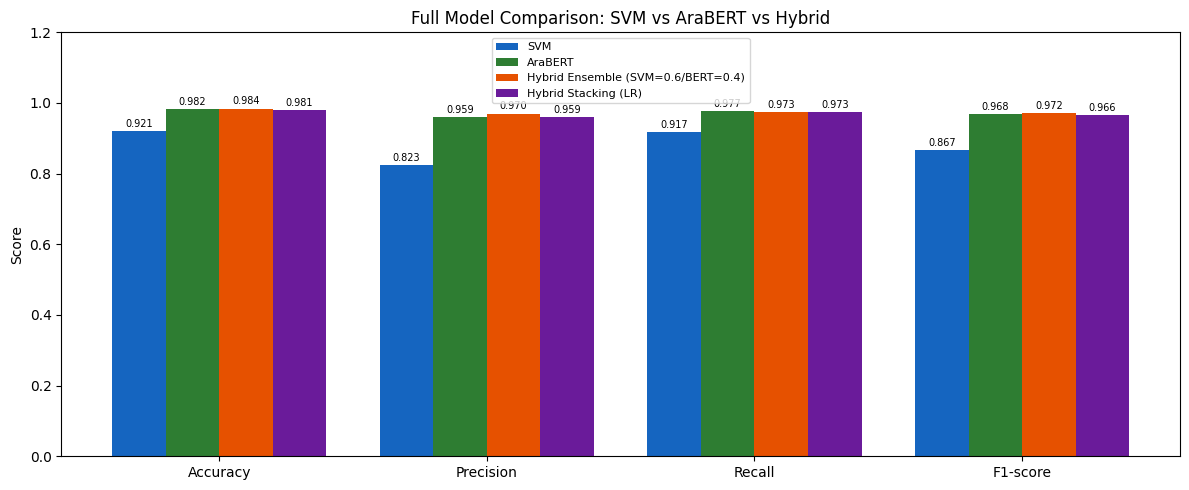

 Saved hybrid_full_comparison.csv


In [95]:
# =====================================================
# Hybrid Step 3: Stacking + Full 4-Model Comparison
# =====================================================
from sklearn.linear_model import LogisticRegression

# --- Train Stacking meta-learner on VALIDATION probabilities ---
meta_X_valid = np.column_stack([svm_valid_probs, valid_probs])
meta_X_test  = np.column_stack([svm_test_scaled, test_probs])

meta_clf = LogisticRegression(class_weight="balanced", random_state=42, C=1.0)
meta_clf.fit(meta_X_valid, np.array(valid_true))

stacking_preds = meta_clf.predict(meta_X_test)

stacking_acc  = accuracy_score(y_test, stacking_preds)
stacking_prec = precision_score(y_test, stacking_preds)
stacking_rec  = recall_score(y_test, stacking_preds)
stacking_f1   = f1_score(y_test, stacking_preds)

print("=== Stacking Results ===")
print("Accuracy :", round(stacking_acc,  4))
print("Precision:", round(stacking_prec, 4))
print("Recall   :", round(stacking_rec,  4))
print("F1-score :", round(stacking_f1,   4))
print()
print(classification_report(y_test, stacking_preds, digits=4))

# --- Best Ensemble preds ---
best_row = ensemble_df.sort_values("F1-score", ascending=False).iloc[0]
best_hybrid = (best_row["SVM Weight"] * svm_test_scaled +
               best_row["BERT Weight"] * test_probs)
best_hybrid_preds = (best_hybrid >= best_row["Threshold"]).astype(int)

# --- Full 4-Model Comparison Table ---
full_df = pd.DataFrame({
    "Model":     ["SVM", "AraBERT",
                  f"Hybrid Ensemble (SVM={best_row['SVM Weight']}/BERT={best_row['BERT Weight']})",
                  "Hybrid Stacking (LR)"],
    "Accuracy":  [svm_acc,  bert_acc,
                  accuracy_score(y_test, best_hybrid_preds),  stacking_acc],
    "Precision": [svm_prec, bert_prec,
                  precision_score(y_test, best_hybrid_preds), stacking_prec],
    "Recall":    [svm_rec,  bert_rec,
                  recall_score(y_test, best_hybrid_preds),    stacking_rec],
    "F1-score":  [svm_f1,   bert_f1,
                  f1_score(y_test, best_hybrid_preds),        stacking_f1],
})

print("=== Final 4-Model Comparison ===")
display(full_df)

# --- Bar Chart ---
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.2
colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(full_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=row["Model"], color=colors[i])
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=7)

ax.set_ylabel("Score")
ax.set_title("Full Model Comparison: SVM vs AraBERT vs Hybrid")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=8)
ax.set_ylim(0, 1.2)
plt.tight_layout()
plt.show()

# --- Save ---
full_df.to_csv("hybrid_full_comparison.csv", index=False, encoding="utf-8-sig")
print(" Saved hybrid_full_comparison.csv")

## تنزيل النتائج من Colab

In [96]:
from google.colab import files

files.download("model_comparison_results.csv")
files.download("svm_test_predictions.csv")
files.download("arabert_test_predictions.csv")
files.download("train_clean_final.csv")
files.download("valid_clean_final.csv")
files.download("test_clean_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>